## In this notebook we use various training strategies to train our PNN on MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
sys.path.append('G:/Utilisateurs/anas.skalli/Desktop/ONN_experiments/Simulation/Nonlinear_oscillator_net/nonlinear_oscillator_network/Utils')

from NN_utils import *
import torch
import torch.nn as nn
from torchvision import datasets, transforms
#from torchsummary import summary
import time
from types import SimpleNamespace
import pickle
import gc
from optimization_algorithms import *

In [2]:
transform_data = transforms.Compose([
    transforms.ToTensor()
    #transforms.Normalize((0.2868,), (0.3524,))
])

MNIST_train = datasets.MNIST(root='./data', train=True, transform=transform_data, download=True)
MNIST_test = datasets.MNIST(root='./data', train=False, transform=transform_data, download=True)

train_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_train, batch_size=1000, shuffle=True)
test_loader_MNIST = torch.utils.data.DataLoader(dataset=MNIST_test, batch_size=10000, shuffle=False)

X_train_MNIST, Y_train_MNIST = next(iter(train_loader_MNIST))
X_test_MNIST, Y_test_MNIST = next(iter(test_loader_MNIST))

In [ ]:
N_neurons_vec = [5, 10, 20, 30, 50, 75, 100]
#N_neurons_vec = [100]

n_epochs = 100
results = []

stats = 3

start_time = time.time()
for s in range(stats):
    for n_neurons in N_neurons_vec:
    
       
        #Initialize RNN
        
        RNN_params = {
            "N_in": 784,               # e.g., flattened 28x28 FashionMNIST image
            "N_out": 10,               # number of classes in FashionMNIST
            "N_neurons": n_neurons,          # number of hidden units per RNN layer
            "N_layers": 3             # depth of the RNN
        }
        
        model = Oscillator_RNN_dyn(params=RNN_params)
        
        
        
        model.init_esn_weights(reservoir = True)
        model.dt = 0.1
        model.eps_int = 1e-4
        model.alpha=3
        model.max_steps=40
        model.save_activations = False
        
        # for layer in model.W_in:
        #     for param in layer.parameters():
        #         param.requires_grad = False
                
        # model.W_input.weight.requires_grad = False
        # model.W_input.bias.requires_grad = False
        
        
        loss = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        
        print(f'Using {n_neurons} per layer, run {s+1}, number of parameters {model.count_parameters()}')
        D = train_BP_torch(model, n_epochs, train_loader_MNIST, test_loader_MNIST, loss, optimizer)
    
        results.append(D)
        
        del model
        del optimizer
        torch.cuda.empty_cache()
        gc.collect()

end_time = time.time()
print(f'Total time = {end_time- start_time} s')

Using 5 per layer, run 1, number of parameters 4045
Using cuda device
Oscillator_RNN_dyn(
  (W_input): Linear(in_features=784, out_features=5, bias=True)
  (W_in): ModuleList(
    (0-1): 2 x Linear(in_features=5, out_features=5, bias=True)
  )
  (W_recurrent): ModuleList(
    (0-2): 3 x SparseLinear()
  )
  (W_out): Linear(in_features=5, out_features=10, bias=True)
)
Epoch [1/100], Step [1/60], Loss: 2.329305648803711, Test Accuracy: 10.09%
Epoch [1/100], Step [10/60], Loss: 2.3252384662628174, Test Accuracy: 10.09%
Epoch [1/100], Step [20/60], Loss: 2.3241100311279297, Test Accuracy: 10.09%
Epoch [1/100], Step [30/60], Loss: 2.3095791339874268, Test Accuracy: 10.09%
Epoch [1/100], Step [40/60], Loss: 2.309187412261963, Test Accuracy: 10.09%
Epoch [1/100], Step [50/60], Loss: 2.296316146850586, Test Accuracy: 10.09%
Epoch [1/100], Step [60/60], Loss: 2.2870075702667236, Test Accuracy: 10.09%
Epoch [2/100], Step [1/60], Loss: 2.296515464782715, Test Accuracy: 10.09%
Epoch [2/100], Step 

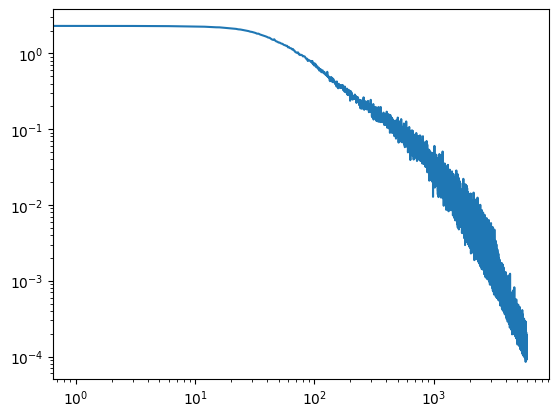

In [4]:
plt.loglog(D['train_loss'])

In [7]:
with open('results/results_paramscan_PNN_BP_MNIST.pkl', 'wb') as f:
    pickle.dump(results, f)     

In [5]:
test_loss_vec = []
test_loss_std = []
test_acc_vec = []
test_acc_std = []
train_loss_vec = []
train_loss_std = []
n_params = []

dummy = np.reshape(results, [stats, len(N_neurons_vec)])
top_k = 10  # Number of best points to average over

for i in range(len(N_neurons_vec)):
    train_loss_runs = []
    test_loss_runs = []
    test_acc_runs = []
    
    for j in range(stats):
        train_loss = np.array(dummy[j, i]['train_loss'])
        test_loss = np.array(dummy[j, i]['test_loss'])
        test_acc = np.array(dummy[j, i]['test_acc'])

        # Take mean over best 10 points for each metric
        best_train_loss = np.mean(np.sort(train_loss)[:top_k])
        best_test_loss = np.mean(np.sort(test_loss)[:top_k])
        best_test_acc = np.mean(np.sort(test_acc)[-top_k:])  # top accuracy

        train_loss_runs.append(best_train_loss)
        test_loss_runs.append(best_test_loss)
        test_acc_runs.append(best_test_acc)

    train_loss_vec.append(np.mean(train_loss_runs))
    test_loss_vec.append(np.mean(test_loss_runs))
    test_acc_vec.append(np.mean(test_acc_runs))

    train_loss_std.append(np.std(train_loss_runs))
    test_loss_std.append(np.std(test_loss_runs))
    test_acc_std.append(np.std(test_acc_runs))

    n_params.append(dummy[0, i]['n_params'])

n_params = np.array(n_params)


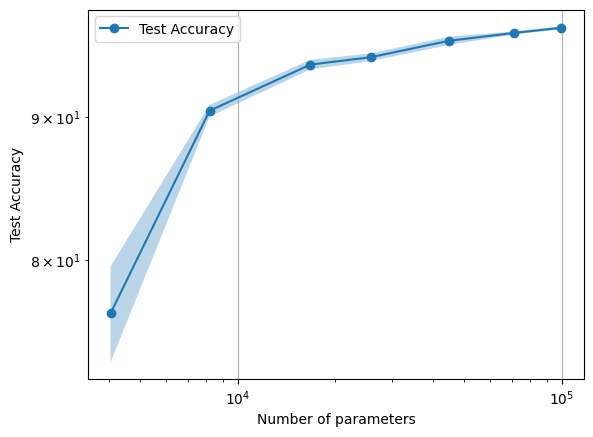

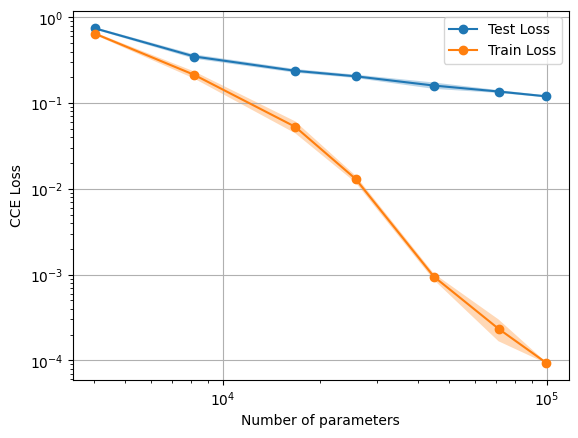

In [6]:
# Accuracy plot
plt.figure()
plt.loglog(n_params, test_acc_vec, '-o', label='Test Accuracy')
plt.fill_between(n_params,
                 np.array(test_acc_vec) - np.array(test_acc_std),
                 np.array(test_acc_vec) + np.array(test_acc_std),
                 alpha=0.3)
plt.xlabel('Number of parameters')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.loglog(n_params, test_loss_vec, '-o', label='Test Loss')
plt.fill_between(n_params,
                 np.array(test_loss_vec) - np.array(test_loss_std),
                 np.array(test_loss_vec) + np.array(test_loss_std),
                 alpha=0.3)

plt.loglog(n_params, train_loss_vec, '-o', label='Train Loss')
plt.fill_between(n_params,
                 np.array(train_loss_vec) - np.array(train_loss_std),
                 np.array(train_loss_vec) + np.array(train_loss_std),
                 alpha=0.3)

plt.xlabel('Number of parameters')
plt.ylabel('CCE Loss')
plt.grid(True)
plt.legend()
plt.show()